Data Analysis of Discharging Brizo Batteries

In [2]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
import os
import math

from utils.data.db import Database, CommonData

import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

%matplotlib widget

DIR = os.path.dirname(os.path.abspath("12_21_24_discharging.ipynb"))

In [3]:
DATA_FILE_PATH = os.path.join(DIR, "cached_data/12_20_raw.pkl")
#START_TIME = datetime.strptime("DD/MM/YYYY 00:00:00", "%m/%d/%Y %H:%M:%S")
#END_TIME = datetime.strptime("DD/MM/YYYY 23:59:59", "%m/%d/%Y %H:%M:%S")

try:
    #raise LookupError("uncomment if you need to reload data")
    with open(DATA_FILE_PATH, mode="rb") as file:
        data = pkl.load(file)
except (FileNotFoundError, LookupError):
    db = Database("12_20_cycling")
    data: dict[str, pd.DataFrame] = {}
    for parts in [
        db.fetch_common(name)
        for name in [
            "pack_current",
            "pack_voltage",
            "cell_voltages",
        ]
    ]:
        data.update(parts)
    with open(DATA_FILE_PATH, mode="wb") as file:
        pkl.dump(data, file)

[]


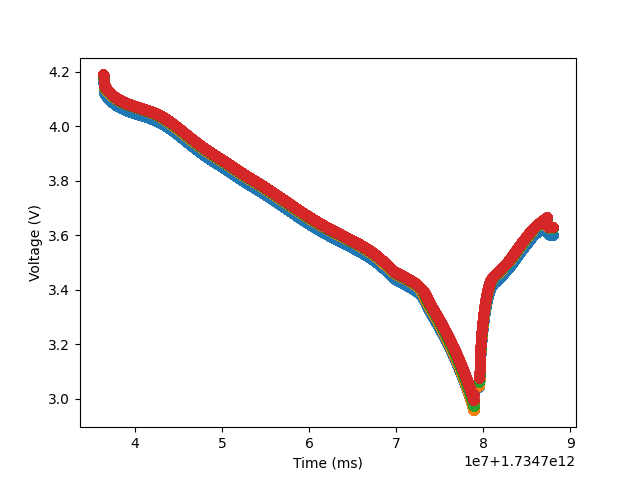

In [4]:
from utils.data.time import to_millis

# Take times (in milliseconds) where we turned current on/off
jumps = [(1734736422588, 1734778886092)]
voltages = []
# Plot voltages from first BMS 
plt.figure()
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_1"])
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_2"])
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_3"])
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_4"])
plt.ylabel("Voltage (V)")
plt.xlabel("Time (ms)")
print(voltages)
# Internal Resistance Value taken from previous test
internal_res = 0.0871 



In [5]:
from utils.data.process import align_df, remove_spikes, smooth_data

# takes intervals excluding non-discharging and removing the bad modules
keep_times = [
    (1734736422588, 1734778886092)
]

min_time = max([data[f"BMS_VOLTAGE{i + 1}"]["time"].iloc[0] for i in range(7)]) // 1000 + 1
max_time = min([data[f"BMS_VOLTAGE{i + 1}"]["time"].iloc[-1] for i in range(7)]) // 1000 - 1

time_uniform = np.arange(min_time * 1000, max_time * 1000, 1000)
badModules = [1,11,12,13,15,24,25,26,28]
df = pd.concat(
    [
        align_df(
            data[f"BMS_VOLTAGE{i + 1}"],
            time_uniform,
            [f"module_{i * 4 + j + 1}" for j in range(4)],
        )
        for i  in range(7)
    ], 
    axis = 1
)
for mod in badModules:
    df = df.drop("module_"+str(mod),axis=1)
indices = [
    (
        np.searchsorted(time_uniform, start),
        np.searchsorted(time_uniform, end),
    )
    for start, end in keep_times
]

df = df.iloc[np.r_[*[slice(start, end) for start, end in indices]]]
df = df.reset_index(drop=True)

spikeless = remove_spikes(df, threshold=5)
modules = smooth_data(spikeless, 1)
display(modules)


,module_2,module_3,module_4,module_5,module_6,module_7,module_8,module_9,module_10,module_14,module_16,module_17,module_18,module_19,module_20,module_21,module_22,module_23,module_27
0,4.154334,4.158900,4.164801,4.161567,4.155201,4.159199,4.162234,4.161832,4.157734,4.156134,4.168466,4.167788,4.163734,4.163401,4.167234,4.153400,4.155466,4.156967,4.161700
1,4.154165,4.158731,4.164623,4.161397,4.155043,4.159038,4.162061,4.161634,4.157569,4.155966,4.168285,4.167587,4.163568,4.163232,4.167054,4.153255,4.155314,4.156818,4.161528
2,4.153996,4.158562,4.164444,4.161226,4.154884,4.158877,4.161887,4.161434,4.157404,4.155798,4.168103,4.167384,4.163403,4.163063,4.166873,4.153108,4.155162,4.156668,4.161355
3,4.153826,4.158391,4.164264,4.161054,4.154725,4.158713,4.161712,4.161234,4.157238,4.155629,4.167920,4.167180,4.163235,4.162892,4.166691,4.152961,4.155008,4.156517,4.161181
4,4.153653,4.158218,4.164082,4.160880,4.154563,4.158548,4.161535,4.161031,4.157069,4.155457,4.167734,4.166974,4.163066,4.162719,4.166507,4.152812,4.154852,4.156364,4.161004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42459,2.958401,2.974726,2.995539,2.991565,2.971347,2.986086,2.998899,2.992728,2.981256,2.987058,3.016190,3.008018,2.996130,2.986507,3.010134,2.996252,2.999279,2.998211,3.002794
42460,2.958272,2.974602,2.995429,2.991453,2.971234,2.985979,2.998786,2.992613,2.981142,2.986944,3.016092,3.007913,2.996023,2.986395,3.010026,2.996150,2.999184,2.998109,3.002691
42461,2.958143,2.974477,2.995319,2.991340,2.971122,2.985872,2.998672,2.992499,2.981028,2.986829,3.015995,3.007809,2.995915,2.986282,3.009918,2.996048,2.999089,2.998006,3.002589
42462,2.958014,2.974352,2.995209,2.991228,2.971011,2.985765,2.998557,2.992384,2.980914,2.986715,3.015897,3.007704,2.995807,2.986170,3.009809,2.995945,2.998995,2.997903,3.002487


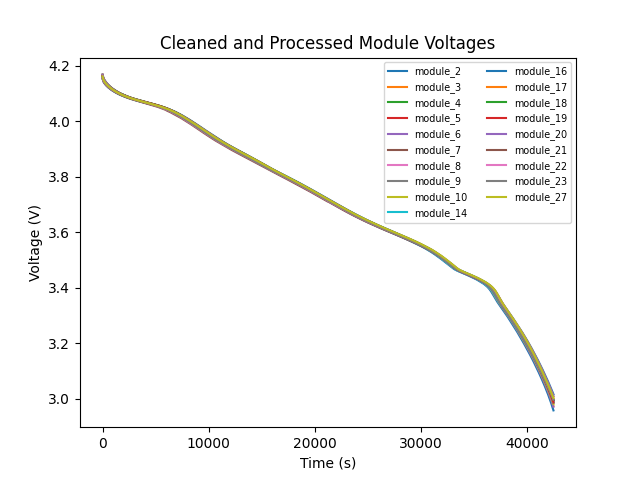

In [6]:
from utils.visualize.plotters import df_plot

# plot preprocessed data
fig = plt.figure()
ax = fig.subplots()

df_plot(ax, modules)

plt.title("Cleaned and Processed Module Voltages")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend(ncols=2, fontsize="x-small")

           module_2      module_3      module_4      module_5      module_6  \
2.500  45503.424670  45668.222233  45970.591878  45937.735607  45670.223734   
2.501  45498.693342  45663.448511  45965.622962  45932.760199  45665.393243   
2.502  45493.956184  45658.668948  45960.648081  45927.778811  45660.556861   
2.503  45489.213186  45653.883533  45955.667224  45922.791433  45655.714576   
2.504  45484.464337  45649.092255  45950.680380  45917.798053  45650.866378   
...             ...           ...           ...           ...           ...   
4.196   -463.692471   -433.329154   -380.595403   -396.948325   -472.638250   
4.197   -470.534139   -440.728414   -388.508377   -404.397858   -479.849448   
4.198   -477.285907   -448.032042   -396.321148   -411.752517   -486.966644   
4.199   -483.949557   -455.241883   -404.035613   -419.014115   -493.991692   
4.200   -490.526871   -462.359774   -411.653664   -426.184463   -500.926447   

           module_7      module_8      module_9    

Text(0, 0.5, 'Time (s)')

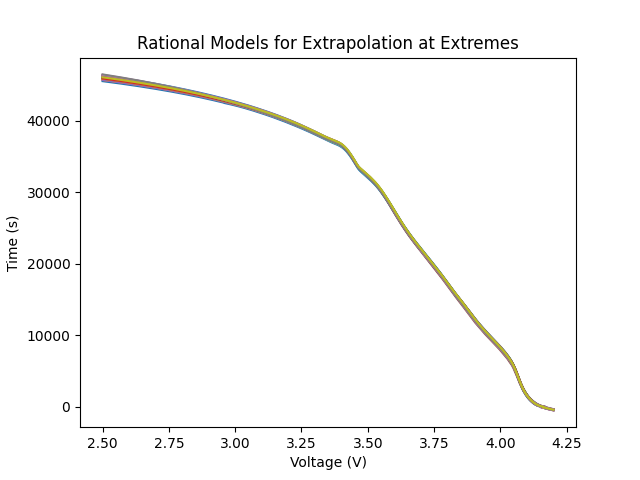

In [7]:
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit
from scipy.stats import norm
import time


def rational(x, a, b, h, k):
    return a / (b * (x - h)) + k


indices = np.arange(2.5, 4.201, 0.001)
extrapolated = pd.DataFrame(index=indices)
modules_copy = modules.copy()
# Per module does voltage vs time and extrapolates
for i in range(1, 29):
    if i in badModules:
        continue
    
    # takes module data and finds desired cutoff indices for curve fitting for extrapolation
    df = modules_copy[f"module_{i}"]
    high_interp_ind = df.index[
        -df.searchsorted(4.09, sorter=np.arange(len(df) - 1, -1, -1))
    ]
    low_interp_ind = df.index[
        -df.searchsorted(3.30, sorter=np.arange(len(df) - 1, -1, -1))
    ]
    high_region = df[:high_interp_ind]
# normal distribution across indices to weight ends of area for better fit between end of data and extrapolated curve
    weights = norm.pdf(
        (high_region.index - high_region.index[-1] / 2),
        0,
        high_region.index[-1] / 4,
    )
    # initial condition to ensure convergence
    p0 = [1, 1, 4, 0]
    popt, _ = curve_fit(
        rational,
        high_region[::-1],
        high_region.index[::-1] / 1000,
        p0,
        weights,
    )
    # sample, fit, and extrapolate higher voltage region (4.2 to highest value)
    sample = np.arange(df.iloc[0], 4.2, 0.001)
    eval = np.vectorize(lambda x: rational(x, *popt))
    fitted = eval(sample)
    # fitted = rational(sample, *[np.repeat(param, len(sample)) for param in popt])
    extrap_high = pd.Series(sample, fitted* 1000)

    # same thing for lower voltage region (lowest value to 2.5)
    low_region = df[low_interp_ind:]
    length = low_region.index[-1] - low_region.index[0]
    weights = norm.pdf(low_region.index - low_interp_ind - length / 2, 0, length / 4)
    p0 = [-1, 1, 3.5, 47]
    popt, _ = curve_fit(
        rational,
        low_region[::-1],
        low_region.index[::-1] / 1000,
        p0,
        weights,
    )

    sample = np.arange(2.5, df.iloc[-1], 0.001)
    eval = np.vectorize(lambda x: rational(x, *popt))
    fitted = eval(sample)
    # fitted = rational(sample, *[np.repeat(param, len(sample)) for param in popt])
    extrap_low = pd.Series(sample, fitted * 1000)

    # combine data with extrapolated parts
    extrap = pd.concat([df, extrap_low, extrap_high]).sort_index()
    # normalize indices
    sample = np.arange(2.5, 4.201, 0.001)

    # ensure monotone so that we can use interpolating splines
    extrap = extrap[extrap.cummin().diff() < 0]
    # interpolates and smooths fully processed data
    smooth = make_interp_spline(extrap[::-1], extrap.index[::-1])

    extrapolated[f"module_{i}"] = smooth(sample)
    

fig = plt.figure()
ax = fig.subplots()

df_plot(ax, extrapolated)
print(extrapolated)
plt.title("Rational Models for Extrapolation at Extremes")
plt.xlabel("Voltage (V)")
plt.ylabel("Time (s)")


[0.0, 0.0, 0.0, 0.0, 0.0, 0.27845060768392216, 0.5653497069986635, 0.861088374372565, 1.1660822409125693, 1.480773453333717, 1.8056328261435217, 2.141162207234748, 2.487897082028301, 2.8464094447516852, 3.2173109694324076, 3.601256517809015, 3.998948026747118, 4.411138824021521, 4.838638428660358, 5.282317900650169, 5.743115814911004, 6.22204494637959, 6.720199767145951, 7.243309284215571, 7.782283905197507, 8.327311873093969, 8.912741047454976, 9.533542515097748, 10.18233280854921, 10.860843837853851, 11.569295404191848, 12.313355658689884, 13.094028400161617, 13.91146224742188, 14.768432876457283, 15.667375767692448, 16.610074281114105, 17.590089209488212, 18.535579778047794, 19.338199857647908, 20.33257252359162, 22.25105124819059, 25.2167935675617, 27.904158933400947, 29.642035617204222, 31.609905297193063, 34.046118404298376, 37.0146718112826, 40.296693549004914, 43.54272093642515, 46.537595586398275, 49.2544210317657, 51.78762630132556, 54.25966876571762, 56.74628487986275, 59.30

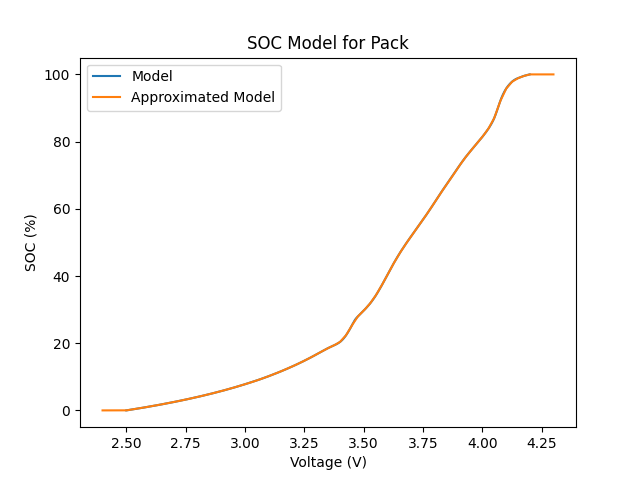

In [8]:
# averages all modules time values per voltage
avgd = extrapolated.mean(axis=1)
# turns into SOC value
soc = (1 - (avgd - avgd.iloc[-1]) / (avgd.iloc[0] - avgd.iloc[-1])) * 100
plt.figure()
plt.plot(soc.index, soc, label="Model")

# approximation for SOC based on analysis
# units in millivolts
max_vol = 4300
min_vol = 2400
step = 25

# interpolation array with padding
interp = (
    [0.0 for _ in range(int((2500 - min_vol) / step))]
    + list(soc[::step])
    + [100.0 for _ in range(int((max_vol - 4200) / step))]
)

# takes in voltage in [2.4, 4.3]
def approx_soc(voltage):
    voltage = voltage * 1000
    idx = int((voltage - min_vol) / step)
    linear_interp = (interp[idx + 1] - interp[idx]) / step
    return interp[idx] + (voltage - min_vol - idx * step) * linear_interp


sample = np.arange(2.4, 4.3001, 0.001)
approx = [approx_soc(v) for v in sample]
plt.plot(sample, approx, label="Approximated Model")
plt.legend()
plt.title("SOC Model for Pack")
plt.xlabel("Voltage (V)")
plt.ylabel("SOC (%)")
print(interp)

In [9]:
# calculates power dissipated
pack_power = (avgd.diff().iloc[500:] * np.arange(3.0, 4.201, 0.001)).sum() * 4 * 28 /  -3.6e+6
print(pack_power)

4.943860943652427
